In [1]:
import os
import re
import argparse
import math
from pathlib import Path
from typing import List, Tuple, Optional
import glob
import json
from concurrent.futures import ProcessPoolExecutor

import pandas as pd
from PIL import Image
from PIL import UnidentifiedImageError

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F

from transformers import (
    CLIPProcessor,
    CLIPModel,
    CLIPTextModel,
    CLIPTokenizer,
    )

# NOTE: diffusers is used only in the generation helper. The training part
# only needs transformers + torch.
from diffusers import AutoencoderKL, UNet2DConditionModel, LMSDiscreteScheduler, StableDiffusionPipeline

# Add wandb for experiment tracking
import wandb
import matplotlib.pyplot as plt


In [3]:
# class ImageCaptionDataset(Dataset):
#     """Simple dataset that reads `image_path, caption` from a CSV file.

#     CSV must contain columns named `image_path` and `caption` (customizable via args).
#     We return PIL images (not tensors) and the caption string so batching can
#     use the CLIPProcessor for images and the CLIPTokenizer for captions.
#     """

#     def __init__(self, csv_path: str, image_col: str = "image_path", caption_col: str = "caption"):
#         df = pd.read_csv(csv_path)
#         if image_col not in df.columns or caption_col not in df.columns:
#             raise ValueError(f"CSV must contain columns '{image_col}' and '{caption_col}'")
#         self.df = df
#         self.image_col = image_col
#         self.caption_col = caption_col

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]
#         img_path = row[self.image_col]
#         caption = str(row[self.caption_col])
#         img = Image.open(img_path).convert("RGB")
#         return img, caption

In [4]:
def read_jsonl_file(file_path):
    """
    Reads a JSONL file and returns a list of Python dictionaries,
    where each dictionary represents a JSON object from a line in the file.
    """
    data = []
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Strip whitespace and check if the line is not empty
                stripped_line = line.strip()
                if stripped_line:
                    try:
                        json_object = json.loads(stripped_line)
                        data.append(json_object)
                    except json.JSONDecodeError as e:
                        print(f"Error decoding JSON on line: {stripped_line}. Error: {e}")
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    return data

file_name = 'laion_metadata_kp.jsonl' # Replace with your JSONL file name
jsonl_data = read_jsonl_file(file_name)

if jsonl_data:
    print(f"Successfully loaded {len(jsonl_data)} JSON objects from '{file_name}'.")
    # You can now work with the list of dictionaries
    for item in jsonl_data[:3]: # Print the first 3 items for demonstration
        print(item)

Successfully loaded 1000000 JSON objects from 'laion_metadata_kp.jsonl'.
{'id': 0, 'url': 'https://en.wahooart.com/Art.nsf/O/8YEAYK/$File/Mary-Stevenson-Cassatt-Young-Woman-Sewing-in-the-Garden-S.JPG', 'text': 'Mary Stevenson Cassatt - Young Woman Sewing in the Garden'}
{'id': 1, 'url': 'https://images.fun.com.au/products/26900/1-2/deluxe-inflatable-adult-godzilla-costume.jpg', 'text': 'Deluxe Inflatable Adult Godzilla Costume'}
{'id': 2, 'url': 'https://slimages.macysassets.com/is/image/MCY/products/1/optimized/9845521_fpx.tif?$thumb$', 'text': "JM Collection Handkerchief-Hem Maxi Skirt, Created for Macy's"}


In [5]:
metadata_df = pd.DataFrame(jsonl_data)
metadata_df.head()

,id,url,text
0,0,https://en.wahooart.com/Art.nsf/O/8YEAYK/$File...,Mary Stevenson Cassatt - Young Woman Sewing in...
1,1,https://images.fun.com.au/products/26900/1-2/d...,Deluxe Inflatable Adult Godzilla Costume
2,2,https://slimages.macysassets.com/is/image/MCY/...,"JM Collection Handkerchief-Hem Maxi Skirt, Cre..."
3,3,https://thumbs1.ebaystatic.com/pict/3911144082...,For LG Phone New Synthetic Leather Vintage ID ...
4,4,https://thumbs.dreamstime.com/t/unusual-cave-h...,"Unusual cave-houses in Los Banos near Guadix, ..."


In [6]:
existing_image_filenames = os.listdir('laion_images_kp')
existing_image_filenames = sorted(existing_image_filenames, key=lambda x: int(re.search(r'\d+', x).group()))
existing_image_ids = [int(re.search(r'\d+', data).group()) for data in existing_image_filenames]

filtered_df = metadata_df[metadata_df['id'].isin(existing_image_ids)]

In [ ]:
filenames_df = pd.DataFrame({"image_path": existing_image_filenames})
filenames_df["id"] = filenames_df["image_path"].str.extract(r"(\d+)").astype(int)

filtered_df["id"] = filtered_df["id"].astype(int)

filtered_df = filtered_df.merge(filenames_df, on="id", how="left", validate="many_to_one")

In [8]:
filtered_df.reset_index(drop=True, inplace=True)
filtered_df.to_csv('filtered_metadata.csv', index=False)

In [9]:
file_extensions = set(filtered_df['image_path'].str.extract(r"(\.\w+)").values.flatten())
file_extensions

{'.0',
 '.aspx',
 '.avif',
 '.gif',
 '.html',
 '.jp2',
 '.jpeg',
 '.jpg',
 '.plain',
 '.png',
 '.svg',
 '.tiff',
 '.vnd',
 '.webp',
 '.x',
 nan}

In [2]:
SUPPORTED_RASTER_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".gif",
    ".avif",
    ".jp2",
    ".tif",
    ".tiff"
}

SKIP_EXTENSIONS = {
    ".svg",
    ".html",
    ".aspx",
    ".plain",
    ".vnd",
    ".x",
    ".0"
}

def resolve_image_path(raw_path, base_dir=None):
    """Normalize image path and optionally join with a base directory."""
    if raw_path is None:
        return None
    if isinstance(raw_path, float) and math.isnan(raw_path):
        return None
    path_str = str(raw_path).strip()
    if not path_str:
        return None
    path_str = path_str.replace("\\", "/")
    path = Path(path_str)
    if not path.is_absolute() and base_dir is not None:
        path = Path(base_dir) / path
    return path

def safe_image_dimensions(path):
    """Return (width, height) for supported raster images or (None, reason)."""
    if path is None:
        return None, None, "missing path"
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix in SKIP_EXTENSIONS or not suffix:
        return None, suffix, f"unsupported extension: {suffix or '<none>'}"
    if suffix not in SUPPORTED_RASTER_EXTENSIONS:
        return None, suffix, f"unsupported extension: {suffix}"
    try:
        with Image.open(path) as img:
            img.load()
            width, height = img.size
    except (UnidentifiedImageError, OSError) as exc:
        return None, suffix, f"{type(exc).__name__}: {exc}"
    return (width, height), suffix, None

### Worker to Filter out images of low dimension

/home/koustav/miniconda3/envs/ie643/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:935: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))
/home/koustav/miniconda3/envs/ie643/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:935: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
/home/koustav/miniconda3/envs/ie643/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:935: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/koustav/miniconda3/envs/ie643/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:935: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 2. 
  warnings.warn(str(msg))
/home/koustav/miniconda3/envs/ie643/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:935: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 2. 
  warnings.warn(str(msg))
/home/koustav/miniconda3/envs/ie643/lib/python3.12/site-packages/PIL

Status summary: {'ok': 616755, 'unreadable': 12869, 'too_small': 26}


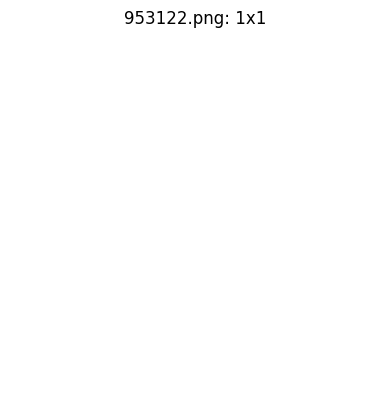

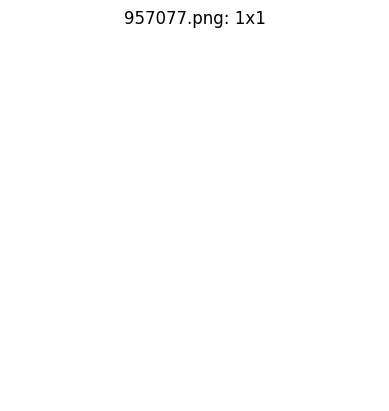

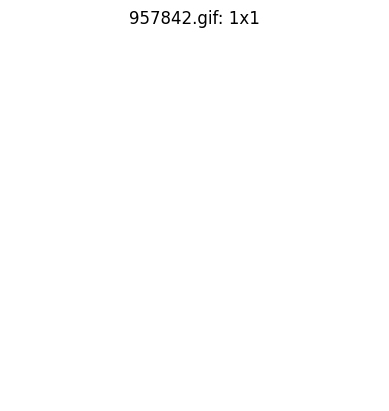

Unreadable files (kept only for reference, not deleted):
  /home1/koustav/Image_to_Image_Diffusion/laion_images_kp/12.svg
  /home1/koustav/Image_to_Image_Diffusion/laion_images_kp/23.png
  /home1/koustav/Image_to_Image_Diffusion/laion_images_kp/89.png
  /home1/koustav/Image_to_Image_Diffusion/laion_images_kp/124.png
  /home1/koustav/Image_to_Image_Diffusion/laion_images_kp/148.png
Dropped 12895 rows (too small or unreadable).


In [14]:
def _inspect_image_worker(record):
    """Worker helper for ProcessPoolExecutor."""
    idx, image_path, base_dir, min_dimension = record
    resolved = resolve_image_path(image_path, base_dir)
    dims, suffix, error = safe_image_dimensions(resolved)

    result = {
        "index": idx,
        "path": str(resolved) if resolved is not None else None,
        "extension": suffix,
    }

    if dims is None:
        result.update({
            "status": "unreadable",
            "error": error,
        })
        return result

    width, height = map(int, dims)
    result["size"] = (width, height)
    if width < min_dimension or height < min_dimension:
        result.update({
            "status": "too_small",
            "error": error,
        })
    else:
        result["status"] = "ok"
    return result

def parallel_clean_metadata(
    df: pd.DataFrame,
    *,
    base_dir: Optional[Path] = None,
    min_dimension: int = 5,
    max_workers: Optional[int] = None,
    delete_small: bool = True,
    preview_limit: int = 3,
    chunksize: int = 64,
    dry_run: bool = False,
):
    """Parallel image audit that filters unreadable or too-small files.

    Returns cleaned dataframe and a report dataframe describing each inspected file.
    """
    if df.empty:
        print("DataFrame is empty — nothing to audit.")
        return df.copy(), pd.DataFrame()

    if base_dir is not None:
        base_dir = Path(base_dir)

    records_iter = (
        (row.Index, getattr(row, "image_path", None), str(base_dir) if base_dir else None, min_dimension)
        for row in df.itertuples()
    )

    results = []
    with ProcessPoolExecutor(max_workers=max_workers) as pool:
        for result in pool.map(_inspect_image_worker, records_iter, chunksize=chunksize):
            results.append(result)

    report_df = pd.DataFrame(results)
    status_counts = report_df["status"].value_counts(dropna=False).to_dict()
    print("Status summary:", status_counts)

    drop_indices = report_df.loc[report_df["status"] != "ok", "index"].tolist()
    cleaned_df = df.drop(index=drop_indices).reset_index(drop=True)

    small_samples = report_df[report_df["status"] == "too_small"].head(preview_limit)
    for _, sample in small_samples.iterrows():
        path_str = sample.get("path")
        if not path_str:
            continue
        path = Path(path_str)
        if not path.exists():
            continue
        try:
            with Image.open(path) as preview_img:
                plt.imshow(preview_img)
                plt.title(f"{path.name}: {preview_img.width}x{preview_img.height}")
                plt.axis("off")
                plt.show()
        except (UnidentifiedImageError, OSError) as exc:
            print(f"Unable to preview {path}: {exc}")

    if not dry_run:
        if delete_small:
            to_remove = report_df.loc[report_df["status"] == "too_small", "path"].dropna().unique()
            for path_str in to_remove:
                path = Path(path_str)
                if not path.exists():
                    continue
                try:
                    path.unlink()
                except OSError as exc:
                    print(f"Unable to remove {path}: {exc}")

        unreadable_paths = report_df.loc[report_df["status"] == "unreadable", "path"].dropna().unique()
        if unreadable_paths.size > 0:
            print("Unreadable files (kept only for reference, not deleted):")
            for path_str in unreadable_paths[:5]:
                print(f"  {path_str}")

    print(f"Dropped {len(drop_indices)} rows (too small or unreadable).")
    return cleaned_df, report_df

# Example usage (uncomment to run):
filtered_df_parallel, audit_report = parallel_clean_metadata(
    filtered_df,
    base_dir="/home1/koustav/Image_to_Image_Diffusion/laion_images_kp",
    min_dimension=5,
    max_workers=8,
)
filtered_df_parallel.to_csv("filtered_metadata_parallel.csv", index=False)
audit_report.to_csv("image_audit_report.csv", index=False)

In [19]:
print("Filtered: Actual Downloaded Images:",filtered_df.shape[0])
print("Filtered: After removing images < 5px:",filtered_df_parallel.shape[0])

Filtered: Actual Downloaded Images: 629650
Filtered: After removing images < 5px: 616755


In [30]:
filtered_df_parallel.rename(columns={'text': 'caption'}, inplace=True)
filtered_df_parallel.to_csv("filtered_metadata_parallel.csv", index=False)

In [ ]:
# # code to cleanup the dataset by removing images with width or height less than 5 pixels
# for num in range(1, 9):
#     df = pd.read_excel(f'/home1/koustav/laion_processing/laion_subset_batch{num}.xlsx')
#     df['image_path'] = df['image_path'].str.replace(r'\\', '/', regex=True)
#     for idx, row in df.iterrows():
#         img_path = row['image_path']
#         img = Image.open(img_path).convert("RGB")
#         if img.width < 5 or img.height < 5:
#             plt.imshow(img)
#             plt.show()
#             print(f"Invalid image dimensions at {img_path}: {img.size}")
#             os.remove(img_path) # removes the image
#             df.drop(index=idx, inplace=True) # drops the row from dataframe
    
#     df.reset_index(drop=True, inplace=True)
#     df.to_excel(f'/home1/koustav/laion_processing/laion_images_filtered/laion_subset_batch{num}.xlsx', index=False)

In [6]:
filtered_df_parallel = pd.read_csv("/home1/koustav/Image_to_Image_Diffusion/filtered_metadata_parallel.csv")
filtered_df_parallel.head()

,id,url,caption,image_path
0,1,https://images.fun.com.au/products/26900/1-2/d...,Deluxe Inflatable Adult Godzilla Costume,1.jpg
1,2,https://slimages.macysassets.com/is/image/MCY/...,"JM Collection Handkerchief-Hem Maxi Skirt, Cre...",2.jpg
2,4,https://thumbs.dreamstime.com/t/unusual-cave-h...,"Unusual cave-houses in Los Banos near Guadix, ...",4.jpg
3,5,https://cdn.shopify.com/s/files/1/1342/1165/pr...,Fabulous Women watches Retro Design Leather Ba...,5.jpg
4,6,https://plustwodamage.files.wordpress.com/2016...,Rock Band Rivals Review: Back In The Saddle,6.jpg


In [25]:
class ImageCaptionDataset(Dataset):
    """
    Dataset that reads `image_path, caption` from one or more files.

    Usage options:
    - Provide a directory and a prefix; it will load all files matching
      f\"{prefix}_batch*.xlsx\" and f\"{prefix}_batch*.csv\".
    - Or provide an explicit list of files in `files`.

    Required columns: `image_path` and `caption` (customizable via args).

    Returns: (PIL.Image.Image, caption_str)
    """

    def __init__(
        self,
        dir_or_single_csv: Optional[str] = None,
        *,
        prefix: Optional[str] = None,
        image_path_prefix: Optional[str] = None,
        files: Optional[List[str]] = None,
        image_col: str = "image_path",
        caption_col: str = "caption",
        drop_na: bool = True,
        dedupe: bool = True,
        on_image_error: str = "raise",  # "raise" | "skip"
    ):
        """
        Usage
            Load discovered Excel batches:
            dataset = ImageCaptionDataset(".", prefix="laion_subset")

            Load from image directory with batch files elsewhere:
            dataset = ImageCaptionDataset("/path/to/batches", prefix="laion_subset")

            Load explicit file list:
            dataset = ImageCaptionDataset(files=["laion_subset_batch1.xlsx","laion_subset_batch2.xlsx"])

        Args:
            dir_or_single_csv: Either a directory to scan or a single CSV/XLSX file path.
            prefix: If scanning a directory, file prefix like 'laion_subset' to match batches.
            files: Explicit list of CSV/XLSX files to load (overrides directory scan).
            image_col: Column name for image path.
            caption_col: Column name for caption.
            drop_na: Drop rows where required cols are NA/empty.
            dedupe: Drop exact duplicate rows by [image_col, caption_col].
            on_image_error: If 'skip', IOError/UnidentifiedImageError will be skipped on __getitem__.
        """
        if files is None:
            if dir_or_single_csv is None:
                raise ValueError("Provide either files=[...] or dir_or_single_csv")
            if os.path.isdir(dir_or_single_csv):
                if not prefix:
                    raise ValueError("When a directory is provided, 'prefix' is required to discover batch files.")
                # Discover both Excel and CSV batches
                xlsx = sorted(glob.glob(os.path.join(dir_or_single_csv, f"{prefix}_batch*.xlsx")))
                csvs = sorted(glob.glob(os.path.join(dir_or_single_csv, f"{prefix}_batch*.csv")))
                discovered = xlsx + csvs
                if not discovered:
                    raise FileNotFoundError(f"No batch files found matching {prefix}_batch*.xlsx or .csv in {dir_or_single_csv}")
                files = discovered
            else:
                # Single file path
                files = [dir_or_single_csv]

        # Load and concatenate
        frames = []
        for fp in files:
            ext = os.path.splitext(fp)[1].lower()
            if ext in (".xlsx", ".xls"):
                df = pd.read_excel(fp)
            elif ext == ".csv":
                df = pd.read_csv(fp)
            else:
                raise ValueError(f"Unsupported file type: {fp}")
            if image_col not in df.columns or caption_col not in df.columns:
                raise ValueError(f"File {fp} must contain columns '{image_col}' and '{caption_col}'")
            frames.append(df[[image_col, caption_col]])

        if not frames:
            raise ValueError("No data loaded from provided files.")

        df = pd.concat(frames, axis=0, ignore_index=True)

        # Clean up
        if drop_na:
            df = df.dropna(subset=[image_col, caption_col])
        # Normalize to str for caption
        df[caption_col] = df[caption_col].astype(str)
        df[image_col] = df[image_col].str.replace(r'\\', '/', regex=True) # Converting windows paths to unix style for consistency

        if dedupe:
            df = df.drop_duplicates(subset=[image_col, caption_col]).reset_index(drop=True)

        # Optional: filter out non-existing files to avoid runtime errors
        # Keep rows with existing files; others will be handled at __getitem__
        self.image_path_prefix = image_path_prefix
        if self.image_path_prefix:
            self._exists_mask = df[image_col].map(lambda p: isinstance(p, str) and os.path.isfile(os.path.join(self.image_path_prefix, p)))
        else:
            self._exists_mask = df[image_col].map(lambda p: isinstance(p, str) and os.path.isfile(p))
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.caption_col = caption_col
        self.on_image_error = on_image_error
        

        # Build an index of valid rows (existing files first) to avoid many open failures
        self._indices = [i for i, ok in enumerate(self._exists_mask) if ok]

    def __len__(self):
        # Only count rows for which files currently exist
        return len(self._indices)

    def __getitem__(self, idx: int):
        real_idx = self._indices[idx]
        row = self.df.iloc[real_idx]
        img_path = row[self.image_col]
        if self.image_path_prefix:
            img_path = os.path.join(self.image_path_prefix, img_path)
        caption = str(row[self.caption_col])
        try:
            img = Image.open(img_path).convert("RGB")
            if img.width < 5 or img.height < 5:
                print(f"Invalid image dimensions at {img_path}: {img.size}")
                raise IndexError(f"Skipped invalid image at {img_path}: {img.size}")    
            return img, caption
        except (FileNotFoundError, UnidentifiedImageError, OSError) as e:
            if self.on_image_error == "skip":
                # Fall back: try next valid index by raising IndexError to trigger DataLoader re-sample if using sampler
                raise IndexError(f"Skipped corrupted/missing image at {img_path}: {e}")
            raise


In [26]:

ds = ImageCaptionDataset("/home1/koustav/Image_to_Image_Diffusion/filtered_metadata_parallel.csv", image_path_prefix="/home1/koustav/Image_to_Image_Diffusion/laion_images_kp")
print(f"Dataset size: {len(ds)}")

Dataset size: 616754


In [27]:
# class ImageCaptionDataset(Dataset):
#     """
#     Dataset that reads `image_path, caption` from one or more files.

#     Usage options:
#     - Provide a directory and a prefix; it will load all files matching
#       f\"{prefix}_batch*.xlsx\" and f\"{prefix}_batch*.csv\".
#     - Or provide an explicit list of files in `files`.

#     Required columns: `image_path` and `caption` (customizable via args).

#     Returns: (PIL.Image.Image, caption_str)
#     """

#     def __init__(
#         self,
#         dir_or_single_csv: Optional[str] = None,
#         *,
#         prefix: Optional[str] = None,
#         files: Optional[List[str]] = None,
#         image_col: str = "image_path",
#         caption_col: str = "caption",
#         drop_na: bool = True,
#         dedupe: bool = True,
#         on_image_error: str = "raise",  # "raise" | "skip"
#     ):
#         """
#         Usage
#             Load discovered Excel batches:
#             dataset = ImageCaptionDataset(".", prefix="laion_subset")

#             Load from image directory with batch files elsewhere:
#             dataset = ImageCaptionDataset("/path/to/batches", prefix="laion_subset")

#             Load explicit file list:
#             dataset = ImageCaptionDataset(files=["laion_subset_batch1.xlsx","laion_subset_batch2.xlsx"])

#         Args:
#             dir_or_single_csv: Either a directory to scan or a single CSV/XLSX file path.
#             prefix: If scanning a directory, file prefix like 'laion_subset' to match batches.
#             files: Explicit list of CSV/XLSX files to load (overrides directory scan).
#             image_col: Column name for image path.
#             caption_col: Column name for caption.
#             drop_na: Drop rows where required cols are NA/empty.
#             dedupe: Drop exact duplicate rows by [image_col, caption_col].
#             on_image_error: If 'skip', IOError/UnidentifiedImageError will be skipped on __getitem__.
#         """
#         if files is None:
#             if dir_or_single_csv is None:
#                 raise ValueError("Provide either files=[...] or dir_or_single_csv")
#             if os.path.isdir(dir_or_single_csv):
#                 if not prefix:
#                     raise ValueError("When a directory is provided, 'prefix' is required to discover batch files.")
#                 # Discover both Excel and CSV batches
#                 xlsx = sorted(glob.glob(os.path.join(dir_or_single_csv, f"{prefix}_batch*.xlsx")))
#                 csvs = sorted(glob.glob(os.path.join(dir_or_single_csv, f"{prefix}_batch*.csv")))
#                 discovered = xlsx + csvs
#                 if not discovered:
#                     raise FileNotFoundError(f"No batch files found matching {prefix}_batch*.xlsx or .csv in {dir_or_single_csv}")
#                 files = discovered
#             else:
#                 # Single file path
#                 files = [dir_or_single_csv]

#         # Load and concatenate
#         frames = []
#         for fp in files:
#             ext = os.path.splitext(fp)[1].lower()
#             if ext in (".xlsx", ".xls"):
#                 df = pd.read_excel(fp)
#             elif ext == ".csv":
#                 df = pd.read_csv(fp)
#             else:
#                 raise ValueError(f"Unsupported file type: {fp}")
#             if image_col not in df.columns or caption_col not in df.columns:
#                 raise ValueError(f"File {fp} must contain columns '{image_col}' and '{caption_col}'")
#             frames.append(df[[image_col, caption_col]])

#         if not frames:
#             raise ValueError("No data loaded from provided files.")

#         df = pd.concat(frames, axis=0, ignore_index=True)

#         # Clean up
#         if drop_na:
#             df = df.dropna(subset=[image_col, caption_col])
#         # Normalize to str for caption
#         df[caption_col] = df[caption_col].astype(str)
#         df[image_col] = df[image_col].str.replace(r'\\', '/', regex=True) # Converting windows paths to unix style for consistency

#         if dedupe:
#             df = df.drop_duplicates(subset=[image_col, caption_col]).reset_index(drop=True)

#         # Optional: filter out non-existing files to avoid runtime errors
#         # Keep rows with existing files; others will be handled at __getitem__
#         self._exists_mask = df[image_col].map(lambda p: isinstance(p, str) and os.path.isfile(p))
#         self.df = df.reset_index(drop=True)
#         self.image_col = image_col
#         self.caption_col = caption_col
#         self.on_image_error = on_image_error

#         # Build an index of valid rows (existing files first) to avoid many open failures
#         self._indices = [i for i, ok in enumerate(self._exists_mask) if ok]

#     def __len__(self):
#         # Only count rows for which files currently exist
#         return len(self._indices)

#     def __getitem__(self, idx: int):
#         real_idx = self._indices[idx]
#         row = self.df.iloc[real_idx]
#         img_path = row[self.image_col]
#         caption = str(row[self.caption_col])
#         try:
#             img = Image.open(img_path).convert("RGB")
#             if img.width < 5 or img.height < 5:
#                 print(f"Invalid image dimensions at {img_path}: {img.size}")
#                 raise IndexError(f"Skipped invalid image at {img_path}: {img.size}")    
#             return img, caption
#         except (FileNotFoundError, UnidentifiedImageError, OSError) as e:
#             if self.on_image_error == "skip":
#                 # Fall back: try next valid index by raising IndexError to trigger DataLoader re-sample if using sampler
#                 raise IndexError(f"Skipped corrupted/missing image at {img_path}: {e}")
#             raise


In [28]:
# ds = ImageCaptionDataset("/home1/koustav/laion_processing/filtered_metadata_parallel", prefix="laion_subset")
# print(f"Dataset size: {len(ds)}")

### Testing the Dataset and DataLoader

In [6]:
dl = DataLoader(ds, batch_size=8, shuffle=True, collate_fn=collate_batch, num_workers=4)
for images, captions in dl:
    print(f"Size of image: {images[0].size}, dtype: {type(images[0])}")
    print(f"Size of caption: {len(captions[0])}, type: {type(captions[0])}")
    print(f"Batch images: {len(images)}, captions: {len(captions)}")
    break  # Just one batch for demo

Size of image: (180, 242), dtype: <class 'PIL.Image.Image'>
Size of caption: 42, type: <class 'str'>
Batch images: 8, captions: 8


In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model_name = "openai/clip-vit-large-patch14"

In [18]:
processor = CLIPProcessor.from_pretrained(clip_model_name)
clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [ ]:
# code to verify that the images can be processed by the CLIPProcessor and passed through the CLIPModel
# test for the dataloader
dl = DataLoader(ds, batch_size=8, shuffle=True, collate_fn=collate_batch, num_workers=4)
for images, captions in dl:
    print(f"Size of image: {images[0].size}, dtype: {type(images[0])}")
    print(f"Size of caption: {len(captions[0])}, type: {type(captions[0])}")
    print(f"Batch images: {len(images)}, captions: {len(captions)}")
    try:
        inputs = processor(
                    images=images,
                    return_tensors="pt",
                    do_normalize=True,
                    do_resize=True,
                    do_center_crop=True,
                    # Explicitly set mean/std for RGB
                    # These are the defaults for CLIP RGB models
                    # If you use a grayscale model, set mean=[0.5], std=[0.5]
                    # For RGB:
                    # mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711]
                    # If you still get errors, try mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]
                    # But the below should work for openai/clip-vit-large-patch14
                    # If you want to override:
                    mean=[0.48145466, 0.4578275, 0.40821073],
                    std=[0.26862954, 0.26130258, 0.27577711],
                )

    except Exception as e:
        print(f"Error processing image: {e}")
        for img in images:
            print(img.size)
            plt.imshow(img)
            plt.show()
    
    for img in images:
        print(img.size)
        img_inputs = {k: v.to(device) for k, v in inputs.items()}
        try:
            with torch.no_grad():
                img_feats = clip_model.get_image_features(**img_inputs)  # [B, in_dim]
                print(img_feats.shape)
        except Exception as e:
            print(f"Error processing image: {e}")
            plt.imshow(img)
            plt.show()

    break  # Just one batch for demo

### Model Building 

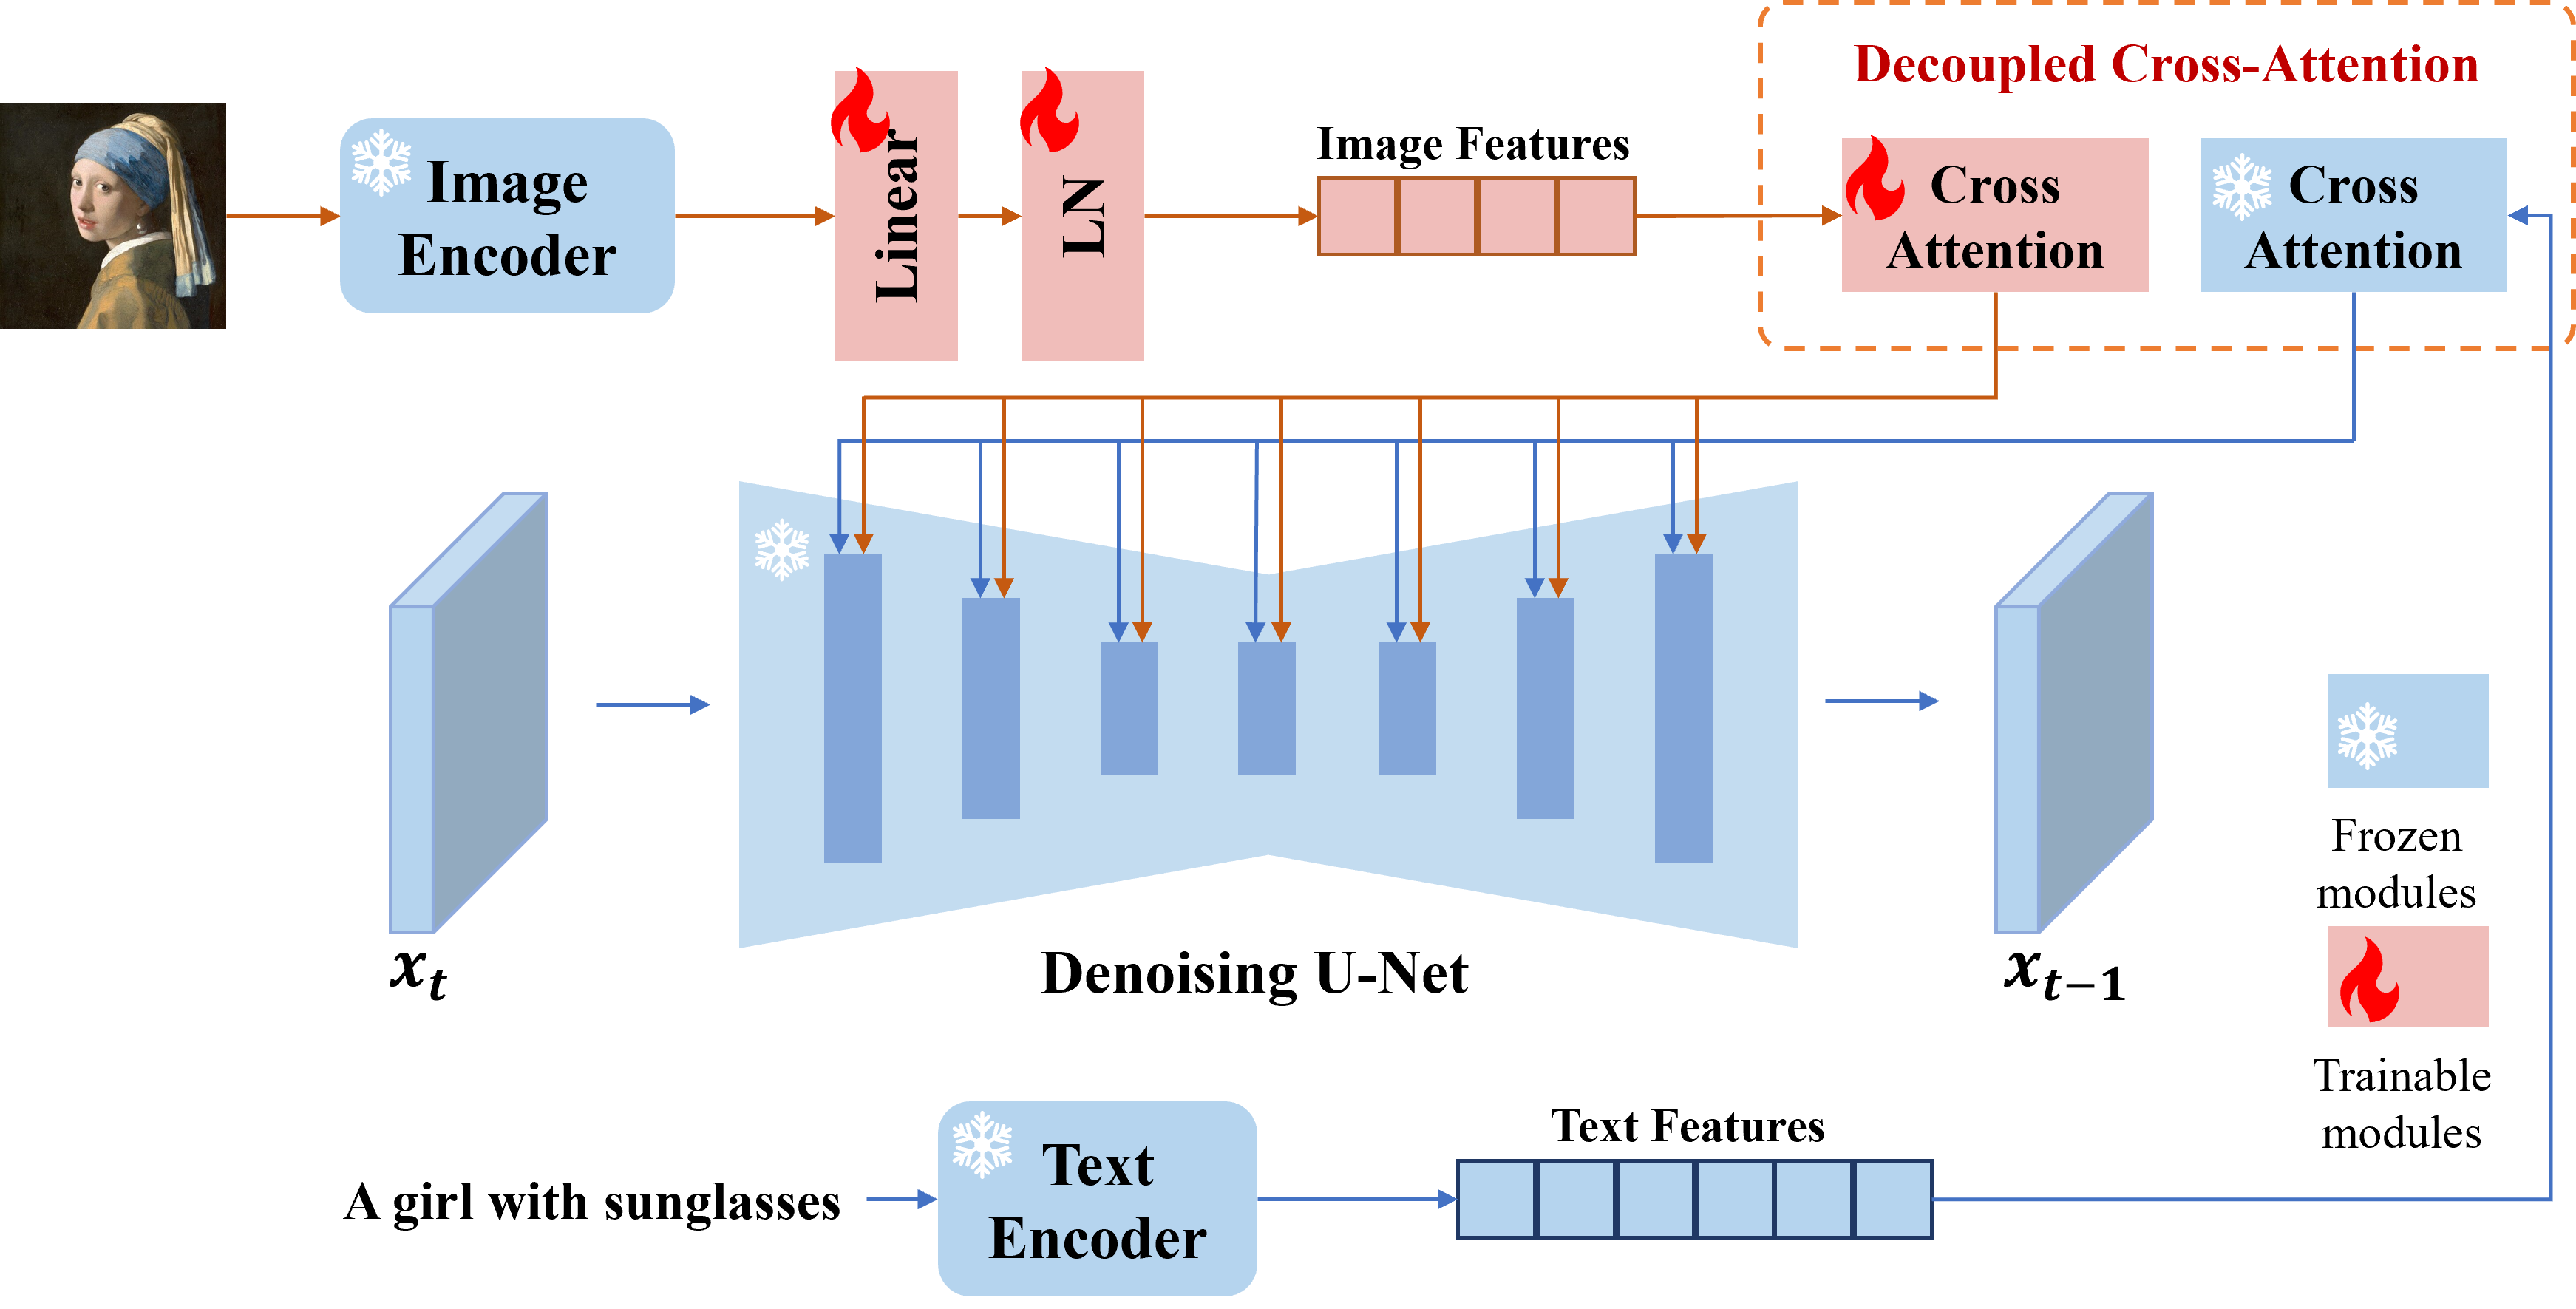

In [30]:
class ImageToTextMapper(nn.Module):
    """MLP that maps CLIP pooled image features (B, I) to a target
    token embedding sequence (B, L, H) where L is text seq length (e.g. 77)
    and H is the text hidden dim (e.g. 768).

    The final linear layer outputs L*H values which are reshaped.
    """

    def __init__(self, in_dim: int, out_seq_len: int, out_dim: int, hidden_dim: int = 4096, num_layers: int = 3, dropout: float = 0.1):
        super().__init__()
        layers = []
        cur = in_dim
        for i in range(num_layers - 1):
            layers.append(nn.Linear(cur, hidden_dim))
            layers.append(nn.GELU())
            layers.append(nn.LayerNorm(hidden_dim))
            layers.append(nn.Dropout(dropout))
            cur = hidden_dim
        # final projection to sequence*dim
        layers.append(nn.Linear(cur, out_seq_len * out_dim))
        self.net = nn.Sequential(*layers)
        self.out_seq_len = out_seq_len
        self.out_dim = out_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, in_dim]
        b = x.shape[0]
        out = self.net(x)
        out = out.view(b, self.out_seq_len, self.out_dim)
        return out

In [29]:
def collate_batch(batch: List[Tuple[Image.Image, str]]):
    images, captions = zip(*batch)
    return list(images), list(captions)

def init_models(clip_model_name: str, device: torch.device):
    """Load CLIP components and return processor, clip_model, text_model, tokenizer.

    We use:
      - CLIPModel (for get_image_features)
      - CLIPTokenizer + CLIPTextModel (for per-token text embeddings targets)

    The function also runs a single dummy pass to infer dims.
    """
    print(f"Loading CLIP model: {clip_model_name}")
    processor = CLIPProcessor.from_pretrained(clip_model_name)
    
    
    # clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)
    clip_model = CLIPModel.from_pretrained(clip_model_name)
    clip_model = send_to_gpus(clip_model)
    tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)
    # text_model = CLIPTextModel.from_pretrained(clip_model_name).to(device)
    text_model = CLIPTextModel.from_pretrained(clip_model_name)
    text_model = send_to_gpus(text_model)

    # Freeze CLIP weights
    clip_model.eval()
    text_model.eval()
    for p in clip_model.parameters():
        p.requires_grad = False
    for p in text_model.parameters():
        p.requires_grad = False

    # run dummy forward to infer dims
    dummy_img = Image.new("RGB", (224, 224), color="white")
    inputs = processor(images=dummy_img, return_tensors="pt")
    with torch.no_grad():
        img_inputs = {k: v.to(device) for k, v in inputs.items()}
        img_feats = clip_model.get_image_features(**img_inputs)

    in_dim = img_feats.shape[-1]
    out_seq_len = tokenizer.model_max_length
    out_dim = text_model.config.hidden_size

    print(f"in_dim (vision pooled features) = {in_dim}")
    print(f"out_seq_len (token length) = {out_seq_len}")
    print(f"out_dim (text hidden size) = {out_dim}")

    return processor, clip_model, tokenizer, text_model, in_dim, out_seq_len, out_dim


In [32]:
def send_to_gpus(model):
    if device == 'cuda' and torch.cuda.device_count() > 1:
        device_ids = [2, 3, 4]  # list of GPU indices
        model = nn.DataParallel(model, device_ids=device_ids)
    model.to(device)
    return model

In [33]:
def train_mapper(
    dataset_csv: str,
    clip_model_name: str,
    out_dir: str,
    device: torch.device,
    epochs: int = 3,
    batch_size: int = 8,
    lr: float = 1e-4,
    hidden_dim: int = 4096,
    num_layers: int = 3,
    save_every: int = 1,
    prefix: str = "laion_subset",
):
    os.makedirs(out_dir, exist_ok=True)

    # Initialize wandb
    wandb.init(
        project="image-to-text-mapper",
        config={
            "dataset_csv": dataset_csv,
            "clip_model_name": clip_model_name,
            "out_dir": out_dir,
            "epochs": epochs,
            "batch_size": batch_size,
            "lr": lr,
            "hidden_dim": hidden_dim,
            "num_layers": num_layers,
            "prefix": prefix,
        }
    )

    # init models
    processor, clip_model, tokenizer, text_model, in_dim, out_seq_len, out_dim = init_models(clip_model_name, device)

    # create mapper
    mapper = ImageToTextMapper(in_dim=in_dim, out_seq_len=out_seq_len, out_dim=out_dim, hidden_dim=hidden_dim, num_layers=num_layers)
    # Use all available GPUs
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for DataParallel")
        mapper = nn.DataParallel(mapper, device_ids = [2, 3, 4])
    mapper = mapper.to(device)

    # dataset + dataloader
    ds = ImageCaptionDataset(dataset_csv, prefix=prefix)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate_batch, num_workers=4)

    optimizer = torch.optim.AdamW(mapper.parameters(), lr=lr, weight_decay=0.01)

    best_loss = float("inf")

    for epoch in range(1, epochs + 1):
        mapper.train()
        running_loss = 0.0
        total_tokens = 0
        total_batches = 0

        for images, captions in dl:
            # images: list[PIL], captions: list[str]
            # Ensure images are RGB
            images = [img.convert("RGB") for img in images]
            # 1) image -> image pooled features
            inputs = processor(
                images=images,
                return_tensors="pt",
                do_normalize=True,
                do_resize=True,
                do_center_crop=True,
                # Explicitly set mean/std for RGB
                # These are the defaults for CLIP RGB models
                # If you use a grayscale model, set mean=[0.5], std=[0.5]
                # For RGB:
                # mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711]
                # If you still get errors, try mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]
                # But the below should work for openai/clip-vit-large-patch14
                # If you want to override:
                mean=[0.48145466, 0.4578275, 0.40821073],
                std=[0.26862954, 0.26130258, 0.27577711],
            )
            img_inputs = {k: v.to(device) for k, v in inputs.items()}
            with torch.no_grad():
                img_feats = clip_model.get_image_features(**img_inputs)  # [B, in_dim]

            # 2) captions -> tokenized -> text encoder outputs (target sequence)
            tokenized = tokenizer(list(captions), padding="max_length", truncation=True, max_length=tokenizer.model_max_length, return_tensors="pt")
            input_ids = tokenized.input_ids.to(device)
            attention_mask = tokenized.attention_mask.to(device)
            with torch.no_grad():
                text_outs = text_model(input_ids=input_ids, attention_mask=attention_mask)
                text_embeds = text_outs.last_hidden_state  # [B, L, H]

            # 3) mapper prediction
            pred = mapper(img_feats)  # [B, L, H]

            # 4) compute masked MSE loss (only over tokens where attention_mask == 1)
            diff2 = (pred - text_embeds).pow(2).mean(dim=-1)  # [B, L]
            masked = diff2 * attention_mask
            loss = masked.sum() / (attention_mask.sum() + 1e-8)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mapper.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item()
            total_batches += 1

        avg_loss = running_loss / max(1, total_batches)
        print(f"Epoch {epoch}/{epochs} — avg masked MSE loss: {avg_loss:.6f}")

        # Log metrics to wandb
        wandb.log({
            "epoch": epoch,
            "avg_loss": avg_loss
        })

        # save checkpoint
        ckpt_path = os.path.join(out_dir, f"mapper_epoch{epoch}.pth")
        torch.save({"state_dict": mapper.state_dict(), "config": {"in_dim": in_dim, "out_seq_len": out_seq_len, "out_dim": out_dim}}, ckpt_path)
        print(f"Saved mapper checkpoint to {ckpt_path}")

        # Optionally log checkpoint as artifact
        wandb.save(ckpt_path)

    # final save
    final_path = os.path.join(out_dir, "mapper.pth")
    torch.save({"state_dict": mapper.state_dict(), "config": {"in_dim": in_dim, "out_seq_len": out_seq_len, "out_dim": out_dim}}, final_path)
    print(f"Saved final mapper to {final_path}")
    wandb.save(final_path)
    wandb.finish()
    return final_path

In [34]:
def generate_variation(
    mapper_path: str,
    clip_model_name: str,
    sd_model_name: str,
    input_image_path: str,
    out_dir: str,
    device: torch.device,
    num_inference_steps: int = 50,
    guidance_scale: float = 3.0,
    strength: float = 0.7,
    seed: int = 42,
):
    """Generate an image variation by:
      - computing CLIP image features for the input image
      - mapping them to text-token embeddings via the trained mapper
      - running a frozen SD denoising loop conditioned on the mapped embeddings

    This follows the img2img approach (encode image to latents, add noise at a
    timestep corresponding to `strength`, then denoise conditioned on mapped tokens).
    """
    os.makedirs(out_dir, exist_ok=True)
    torch.manual_seed(seed)

    # load clip models
    processor = CLIPProcessor.from_pretrained(clip_model_name)
    clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)
    tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)
    text_model = CLIPTextModel.from_pretrained(clip_model_name).to(device)
    # freeze
    clip_model.eval(); text_model.eval()
    for p in clip_model.parameters():
        p.requires_grad = False
    for p in text_model.parameters():
        p.requires_grad = False

    # load mapper
    data = torch.load(mapper_path, map_location=device)
    cfg = data.get("config")
    mapper = ImageToTextMapper(in_dim=cfg["in_dim"], out_seq_len=cfg["out_seq_len"], out_dim=cfg["out_dim"]).to(device)
    state_dict = data["state_dict"]
    # Remove 'module.' prefix if present (from DataParallel)
    if any(k.startswith("module.") for k in state_dict.keys()):
        from collections import OrderedDict
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            new_key = k.replace("module.", "", 1)
            new_state_dict[new_key] = v
        state_dict = new_state_dict
    mapper.load_state_dict(state_dict)
    mapper.eval()

    # load SD pipeline components (we'll use pipeline to get vae, unet, scheduler)
    pipe = StableDiffusionPipeline.from_pretrained(sd_model_name, torch_dtype=torch.float16).to(device)
    pipe.safety_checker = None  # optional
    vae = pipe.vae
    unet = pipe.unet
    scheduler = pipe.scheduler

    # prepare image -> latents
    img = Image.open(input_image_path).convert("RGB")
    init_image = img.resize((512, 512))
    # preprocess for VAE: pipeline has a helper -> but we prepare tensor directly
    preprocess = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ])
    # FIX: convert to float16 for VAE
    img_tensor = preprocess(init_image).unsqueeze(0).to(device=device, dtype=torch.float16)

    # encode with vae
    with torch.no_grad():
        latents = vae.encode(img_tensor).latent_dist.sample()  # [B, C, H/8, W/8]
        latents = latents * vae.config.scaling_factor

    # choose a timestep to add noise based on strength
    scheduler.set_timesteps(num_inference_steps)
    init_timestep = int(strength * (num_inference_steps - 1))
    t = scheduler.timesteps[init_timestep]

    noise = torch.randn_like(latents)
    noisy_latents = scheduler.add_noise(latents, noise, t)

    # compute CLIP image features -> mapper -> token embeddings
    inputs = processor(images=init_image, return_tensors="pt")
    img_inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        img_feats = clip_model.get_image_features(**img_inputs)  # [1, in_dim]
        mapped = mapper(img_feats)  # [1, L, H]

    # compute unconditional embeddings (empty prompt) to allow classifier-free guidance
    uncond_tokens = tokenizer([""], padding="max_length", truncation=True, max_length=tokenizer.model_max_length, return_tensors="pt")
    uncond_input_ids = uncond_tokens.input_ids.to(device)
    uncond_attn = uncond_tokens.attention_mask.to(device)
    with torch.no_grad():
        uncond_emb = text_model(input_ids=uncond_input_ids, attention_mask=uncond_attn).last_hidden_state

    # prepare for guidance: duplicate latents and embeddings
    mapped_emb_cat = torch.cat([uncond_emb, mapped], dim=0)  # [2, L, H]

    # denoising loop
    latents = noisy_latents
    for i, t in enumerate(scheduler.timesteps[init_timestep:]):
        # for classifier-free guidance we duplicate the latents
        latent_model_input = torch.cat([latents] * 2).to(dtype=torch.float16)

        # predict noise
        with torch.no_grad():
            model_out = unet(latent_model_input, t, encoder_hidden_states=mapped_emb_cat.to(dtype=torch.float16)).sample

        eps_uncond, eps_cond = model_out.chunk(2)
        eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        # scheduler step
        step = scheduler.step(eps, t, latents)
        latents = step.prev_sample

    # decode
    with torch.no_grad():
        latents = latents / vae.config.scaling_factor
        dec = vae.decode(latents).sample

    # convert to PIL
    dec = (dec / 2 + 0.5).clamp(0, 1)
    dec = dec.cpu().permute(0, 2, 3, 1).numpy()
    dec_images = [Image.fromarray((img * 255).round().astype('uint8')) for img in (dec[0])]

    # NOTE: above conversion assumes single image; for robust saving we'll use a standard pipeline
    out_path = os.path.join(out_dir, "variation.png")
    # easier: reuse pipeline's decode helper for stable results (if available)
    try:
        image = pipe.numpy_to_pil(dec)[0]
    except Exception:
        # fallback: build PIL from numpy as best effort
        image = Image.fromarray((dec[0] * 255).astype('uint8'))

    image.save(out_path)
    print(f"Saved variation to {out_path}")
    return out_path

In [ ]:
# Notebook-friendly argument handling
device_ids = [2,3,4]
device = f'cuda:{device_ids[0]}'
def get_args(args_dict=None, **kwargs):
    """Return args as an object from a dict or kwargs."""
    class Args:
        pass
    args = Args()
    if args_dict:
        for k, v in args_dict.items():
            setattr(args, k, v)
    for k, v in kwargs.items():
        setattr(args, k, v)
    # Set defaults if not provided
    if not hasattr(args, "clip_model"):
        args.clip_model = "openai/clip-vit-large-patch14"
    if not hasattr(args, "device"):
        # args.device = "cuda" if torch.cuda.is_available() else "cpu"
        args.device = device
        
    if not hasattr(args, "out_dir"):
        args.out_dir = "./mapper_ckpt"
    if not hasattr(args, "epochs"):
        args.epochs = 3
    if not hasattr(args, "batch_size"):
        args.batch_size = 8
    if not hasattr(args, "lr"):
        args.lr = 1e-4
    if not hasattr(args, "hidden_dim"):
        args.hidden_dim = 4096
    if not hasattr(args, "num_layers"):
        args.num_layers = 3
    if not hasattr(args, "sd_model"):
        args.sd_model = "runwayml/stable-diffusion-v1-5"
    if not hasattr(args, "num_inference_steps"):
        args.num_inference_steps = 50
    if not hasattr(args, "guidance"):
        args.guidance = 3.0
    if not hasattr(args, "strength"):
        args.strength = 0.7
    return args

# Main entry point for notebook
def run_main(args):
    device = torch.device(args.device)
    if getattr(args, "mode", None) == "train":
        if not hasattr(args, "dataset"):
            raise ValueError("'dataset' is required for training mode")
        train_mapper(
            dataset_csv=args.dataset,
            clip_model_name=args.clip_model,
            out_dir=args.out_dir,
            device=device,
            epochs=args.epochs,
            batch_size=args.batch_size,
            lr=args.lr,
            hidden_dim=args.hidden_dim,
            num_layers=args.num_layers,
        )
    elif getattr(args, "mode", None) == "gen":
        if not hasattr(args, "mapper") or not hasattr(args, "input_image"):
            raise ValueError("'mapper' and 'input_image' are required for gen mode")
        generate_variation(
            mapper_path=args.mapper,
            clip_model_name=args.clip_model,
            sd_model_name=args.sd_model,
            input_image_path=args.input_image,
            out_dir=args.out_dir,
            device=device,
            num_inference_steps=args.num_inference_steps,
            guidance_scale=args.guidance,
            strength=args.strength,
        )
    else:
        raise ValueError("Unknown mode. Set args.mode to 'train' or 'gen'.")

In [13]:
print("GPUs available:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

GPUs available: 5
GPU 0: NVIDIA GeForce RTX 3080 Ti
GPU 1: NVIDIA GeForce RTX 3080 Ti
GPU 2: NVIDIA RTX A4000
GPU 3: NVIDIA RTX A4000
GPU 4: NVIDIA RTX A4000


In [ ]:
# Example: Run training from notebook
torch.cuda.empty_cache()
args = get_args({
    "mode": "train",
    "dataset": "/home1/koustav/laion_processing/laion_images_filtered",
    "prefix": "laion_subset",
    "clip_model": "openai/clip-vit-large-patch14",
    "out_dir": "./mapper_ckpt",
    "epochs": 10,
    "batch_size": 8,
    "lr": 1e-4,
    "hidden_dim": 4096,
    "num_layers": 3,
})
run_main(args)


wandb: Currently logged in as: syammohan2103 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading CLIP model: openai/clip-vit-large-patch14
in_dim (vision pooled features) = 768
out_seq_len (token length) = 77
out_dim (text hidden size) = 768
in_dim (vision pooled features) = 768
out_seq_len (token length) = 77
out_dim (text hidden size) = 768
Using 5 GPUs for DataParallel
Using 5 GPUs for DataParallel
Epoch 1/10 — avg masked MSE loss: 0.851316
Epoch 1/10 — avg masked MSE loss: 0.851316
Saved mapper checkpoint to ./mapper_ckpt/mapper_epoch1.pth
Saved mapper checkpoint to ./mapper_ckpt/mapper_epoch1.pth
Epoch 2/10 — avg masked MSE loss: 0.793812
Epoch 2/10 — avg masked MSE loss: 0.793812
Saved mapper checkpoint to ./mapper_ckpt/mapper_epoch2.pth
Saved mapper checkpoint to ./mapper_ckpt/mapper_epoch2.pth
Epoch 3/10 — avg masked MSE loss: 0.769238
Epoch 3/10 — avg masked MSE loss: 0.769238
Saved mapper checkpoint to ./mapper_ckpt/mapper_epoch3.pth
Saved mapper checkpoint to ./mapper_ckpt/mapper_epoch3.pth
Epoch 4/10 — avg masked MSE loss: 0.739956
Epoch 4/10 — avg masked MSE l

In [8]:
torch.cuda.empty_cache()  # clear cache before generation

In [13]:
# Example: Run generation from notebook
args = get_args({
    "mode": "gen",
    "mapper": "./mapper_ckpt/mapper.pth",
    "input_image": "input_image3.png",
    "clip_model": "openai/clip-vit-large-patch14",
    "sd_model": "runwayml/stable-diffusion-v1-5",
    "out_dir": "./output",
    "num_inference_steps": 50,
    "guidance": 2.0,
    "strength": 1.0,
    "device": "cuda:0",
})
run_main(args)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Saved variation to ./output/variation.png


In [2]:
# import gc
# model.to("cpu")
# del model, optimizer
# gc.collect()
# torch.cuda.empty_cache()

In [ ]:
num_variations = 5  # how many variations you want

for i in range(num_variations):
    out_path = generate_variation(
        mapper_path=args["mapper"],
        clip_model_name=args["clip_model"],
        sd_model_name=args["sd_model"],
        input_image_path=args["input_image"],
        out_dir=args["out_dir"],
        device=torch.device(args["device"]),
        num_inference_steps=args["num_inference_steps"],
        guidance_scale=args["guidance"],
        strength=args["strength"],
        seed=42 + i,   # different seed each time
    )
    print(f"Saved variation {i+1}: {out_path}")

### Evaluation

In [1]:
!pip install -q torchmetrics
!pip install -q torch-fidelity
!pip install -q torchmetrics[image]

In [3]:
import torch
from torch import rand
from torchmetrics.image.fid import FrechetInceptionDistance
fid = FrechetInceptionDistance(feature=64)
# generate two slightly overlapping image intensity distributions
imgs_dist1 = torch.randint(0, 200, (100, 3, 299, 299), dtype=torch.uint8)
imgs_dist2 = torch.randint(100, 255, (100, 3, 299, 299), dtype=torch.uint8)
fid.update(imgs_dist1, real=True)
fid.update(imgs_dist2, real=False)
fid.compute()

tensor(12.6871)

In [ ]:
# Function to preprocess a single image
def preprocess_image(image):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])
    return transform(image).unsqueeze(0) # Add batch dimension


# Use the images already loaded in the notebook
real_image = gen_img_gen_cap
generated_image = gen_img_ori_cap

# Preprocess the images
real_image_tensor = preprocess_image(real_image)
generated_image_tensor = preprocess_image(generated_image)

# Ensure you have images loaded
if real_image_tensor.size(0) > 0 and generated_image_tensor.size(0) > 0:
    # Update the FID metric with the two sets of images
    fid.update(real_image_tensor, real=True)
    fid.update(generated_image_tensor, real=False)

    # Compute the FID score
    fid_score = fid.compute()

    print(f"FID score: {fid_score}")
else:
    print("Could not load images. Please check the image variables.")